In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('spam.csv', encoding = 'latin1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.drop(columns = {'Unnamed: 2','Unnamed: 3', 'Unnamed: 4'}, axis = 1, inplace = True)

In [5]:
df.rename(columns = {'v1':'label', 'v2' : 'email'},inplace = True)

In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
le = LabelEncoder()
y = df['label']
y = le.fit_transform(y)

In [8]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [9]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

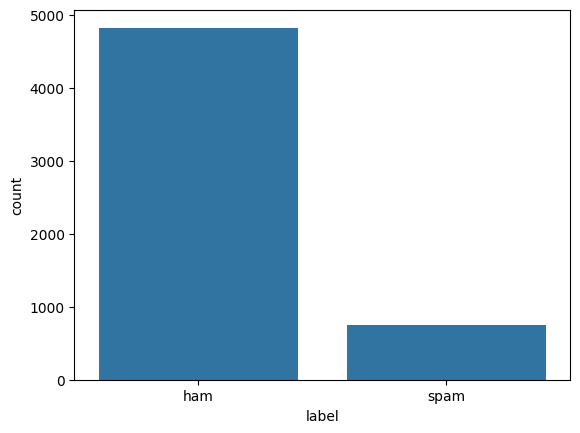

In [10]:
sns.barplot(df['label'] .value_counts())

# Text cleaning

In [11]:
import nltk
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string 
from bs4 import BeautifulSoup
import re

lowercasing  
html parser   
br tags   
removing urls  
remove punctuation  
remove stopwords  
stemming / lemmatization 

In [12]:
stp = stopwords.words('english')

In [13]:
stp[:10]

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [ ]:
def cleanup(text):
    text = text.lower()

    soup = BeautifulSoup(text, 'html.parser')
    text = soup.get_text(separator = ' ')

    text = re.sub(r'[^a-zA-Z0-9\s]','', text)


    lem = WordNetLemmatizer()
    text = ' '.join([lem.lemmatize (w) for w in text.split()])
    

    text = ' '.join([w for w  in text.split() if w not in stp])
    return text  
    
    

In [15]:
df['email'] = df['email'].apply(cleanup)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


In [17]:
tfidf = TfidfVectorizer()

In [18]:
X = df['email']

In [19]:
X_train_raw,X_test_raw,y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 59)

In [20]:
X_train_vec = tfidf.fit_transform(X_train_raw)
X_test_vec = tfidf.transform(X_test_raw)

In [21]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score,f1_score, roc_auc_score,precision_score,recall_score, roc_curve

In [22]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(random_state=59)
}

In [23]:
def training(models,X_train,X_test,y_train,y_test):
    results = []
    import time
    for name,model in models.items():
        
        start= time.perf_counter()
        model.fit(X_train,y_train)
        pred = model.predict(X_test)
        
        ac = accuracy_score(y_test,pred)
        f1 = f1_score(y_test,pred)
        end = time.perf_counter()

        results.append({
            'Model':name,
            'Accuracy':ac,
            'F1_score':f1,
            "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred),
            'Time_taken':end-start
        })
    return pd.DataFrame(results) 

In [24]:
result= training(models,X_train_vec,X_test_vec,y_train,y_test)

In [25]:
result

,Model,Accuracy,F1_score,Precision,Recall,Time_taken
0,Naive Bayes,0.968610,0.855967,1.000000,0.748201,0.004767
1,Logistic Regression,0.967713,0.854839,0.972477,0.762590,0.014635
2,Linear SVM,0.982960,0.928839,0.968750,0.892086,0.007252
3,Random Forest,0.981166,0.918288,1.000000,0.848921,0.904816


In [26]:
result= result.sort_values('Accuracy',ascending=False)


In [27]:
result

,Model,Accuracy,F1_score,Precision,Recall,Time_taken
2,Linear SVM,0.982960,0.928839,0.968750,0.892086,0.007252
3,Random Forest,0.981166,0.918288,1.000000,0.848921,0.904816
0,Naive Bayes,0.968610,0.855967,1.000000,0.748201,0.004767
1,Logistic Regression,0.967713,0.854839,0.972477,0.762590,0.014635


# Using lstm

In [28]:
import tensorflow as tf 
from tensorflow.keras import layers 
from tensorflow.keras.layers import TextVectorization

2026-07-08 14:20:57.275625: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-08 14:20:57.283167: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-08 14:20:57.293203: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-08 14:20:57.296306: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-08 14:20:57.305050: I tensorflow/core/platform/cpu_feature_guar

In [29]:
vectorizer=TextVectorization(
    max_tokens=8000,
    output_sequence_length=200
)

I0000 00:00:1783500658.179050   27123 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783500658.208468   27123 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783500658.210776   27123 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783500658.213664   27123 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [30]:
vectorizer.adapt(X_train_raw)
X_train = vectorizer(X_train_raw)
X_test = vectorizer(X_test_raw)


In [31]:
vocabulary = vectorizer.get_vocabulary()
vocabulary[:10]

['', '[UNK]', 'u', 'call', '2', 'im', 'ur', 'get', 'go', 'dont']

In [32]:
size = len(vectorizer.get_vocabulary())
size

7788

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping 

In [34]:
model = Sequential([
    Embedding(size, 128),
    LSTM(64, return_sequences=True, dropout=0.3),
    Bidirectional(LSTM(32)),  
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

In [35]:
early_stop = EarlyStopping(
    patience = 4,
    monitor = 'val_loss',
    verbose = 1,
    restore_best_weights = True,
)

In [36]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [37]:
history = model.fit(X_train, y_train, batch_size = 64, callbacks = [early_stop], validation_data = (X_test, y_test), epochs = 20)

Epoch 1/20


2026-07-08 14:21:01.068967: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9053 - loss: 0.2650 - val_accuracy: 0.9722 - val_loss: 0.1085
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9829 - loss: 0.0733 - val_accuracy: 0.9857 - val_loss: 0.0641
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9942 - loss: 0.0309 - val_accuracy: 0.9848 - val_loss: 0.0737
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9984 - loss: 0.0142 - val_accuracy: 0.9865 - val_loss: 0.0678
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9987 - loss: 0.0083 - val_accuracy: 0.9874 - val_loss: 0.0626
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9998 - loss: 0.0047 - val_accuracy: 0.9865 - val_loss: 0.0721
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9998 - loss: 0.0033 - val_accuracy: 0.9874 - val_loss: 0.0739
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9982 - loss: 0.0069 - val_accuracy: 0.9839 - val_loss: 0.

In [38]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

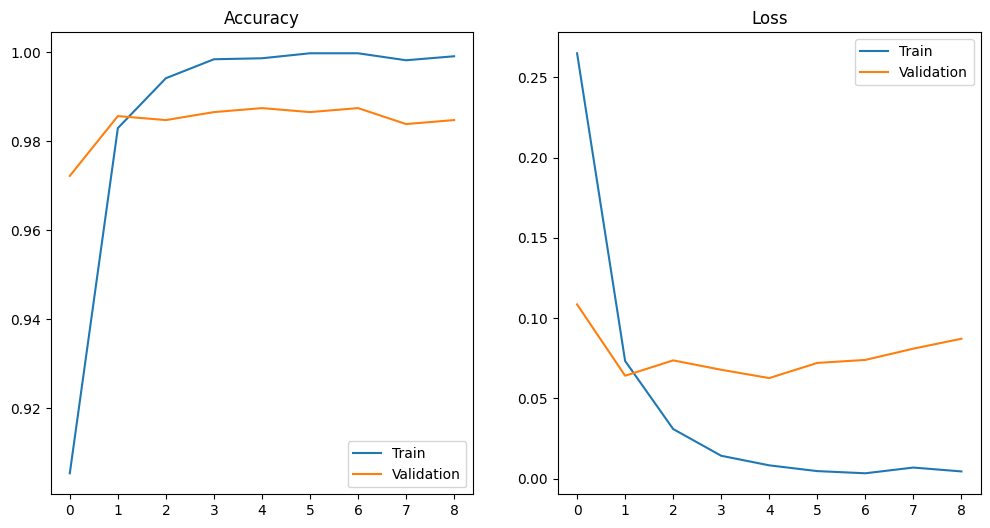

In [39]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("Loss")

plt.show()

In [40]:
y_pred = model.predict(X_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [41]:
y_pred = np.where(y_pred>=0.5, 1,0)

In [42]:
ac=accuracy_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
roc_auc=roc_auc_score(y_test,y_pred)

print("Accuracy Score: ",ac)
print("F1 Score: ",f1)
print("ROC-AUC Score: ",roc_auc)


Accuracy Score:  0.9874439461883409
F1 Score:  0.9477611940298507
ROC-AUC Score:  0.9558099422101664


In [43]:
lstm_result = pd.DataFrame({
    'Model': ['LSTM'],
    'Accuracy': [ac],
    'F1_score': [f1],
    'Precision': [precision_score(y_test, y_pred)],
    'Recall': [recall_score(y_test, y_pred)],
    'Time_taken': [None]
})

In [44]:
lstm_result

,Model,Accuracy,F1_score,Precision,Recall,Time_taken
0,LSTM,0.987444,0.947761,0.984496,0.913669,None


In [45]:
result = pd.concat([result,lstm_result],axis=0)

/tmp/ipykernel_27123/1440602602.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([result,lstm_result],axis=0)


In [46]:
result.sort_values('Accuracy',ascending=False,inplace = True)

In [47]:
result 

,Model,Accuracy,F1_score,Precision,Recall,Time_taken
0,LSTM,0.987444,0.947761,0.984496,0.913669,NaN
2,Linear SVM,0.982960,0.928839,0.968750,0.892086,0.007252
3,Random Forest,0.981166,0.918288,1.000000,0.848921,0.904816
0,Naive Bayes,0.968610,0.855967,1.000000,0.748201,0.004767
1,Logistic Regression,0.967713,0.854839,0.972477,0.762590,0.014635


In [50]:
model.save('Spam_detection.keras')
import pickle

with open("vocabulary.pkl", "wb") as f:
    pickle.dump(vocabulary, f)